# Блок 2

## Задача 1
Дана таблица посещаемости сервиса по месяцам.  
Проанализируй исторические данные и спрогнозируй количество пользователей на следующие 12 месяцев.  
**Dataset:** `newborns_stats.csv`

In [19]:
import pandas as pd

df = pd.read_csv('./newborns_stats.csv')
df

,year,month,c1,cat1,target
0,2015,1,NaN,0,12346
1,2015,2,NaN,0,11210
2,2015,3,40.045,0,12237
3,2015,4,39.860,0,12685
4,2015,5,42.367,1,12881
...,...,...,...,...,...
118,2024,11,34.979,2,9751
119,2024,12,34.646,0,9225
120,2025,1,32.259,0,8927
121,2025,2,30.858,0,8152


Перобразуем индекс в дату 

In [20]:
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df = df.sort_values('date').set_index('date')
df

,year,month,c1,cat1,target
date,,,,,
2015-01-01,2015,1,NaN,0,12346
2015-02-01,2015,2,NaN,0,11210
2015-03-01,2015,3,40.045,0,12237
2015-04-01,2015,4,39.860,0,12685
2015-05-01,2015,5,42.367,1,12881
...,...,...,...,...,...
2024-11-01,2024,11,34.979,2,9751
2024-12-01,2024,12,34.646,0,9225
2025-01-01,2025,1,32.259,0,8927


Мы должны предсказать количество пользователей на следующие **12 месяцев**. Для временных рядов можно использовать метод экспоненциального сглаживания, поскольку он хорошо подходит для предсказания трендов на исторических данных, а также в нем учитывается сезонность и шум.

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# установим месячную частоту
ts = df['target'].asfreq('MS')

model = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)
fit = model.fit(optimized=True)

# прогноз
forecast = fit.forecast(12)

result = pd.DataFrame({
    'year_month': forecast.index.strftime('%Y-%m'),
    'predicted_users': forecast.round().astype(int)
})

print(result.to_string(index=False))

year_month  predicted_users
   2025-04             7699
   2025-05             8173
   2025-06             8619
   2025-07             9168
   2025-08             8890
   2025-09             7889
   2025-10             8076
   2025-11             7307
   2025-12             7158
   2026-01             6844
   2026-02             6071
   2026-03             6826


Визуализация прогноза

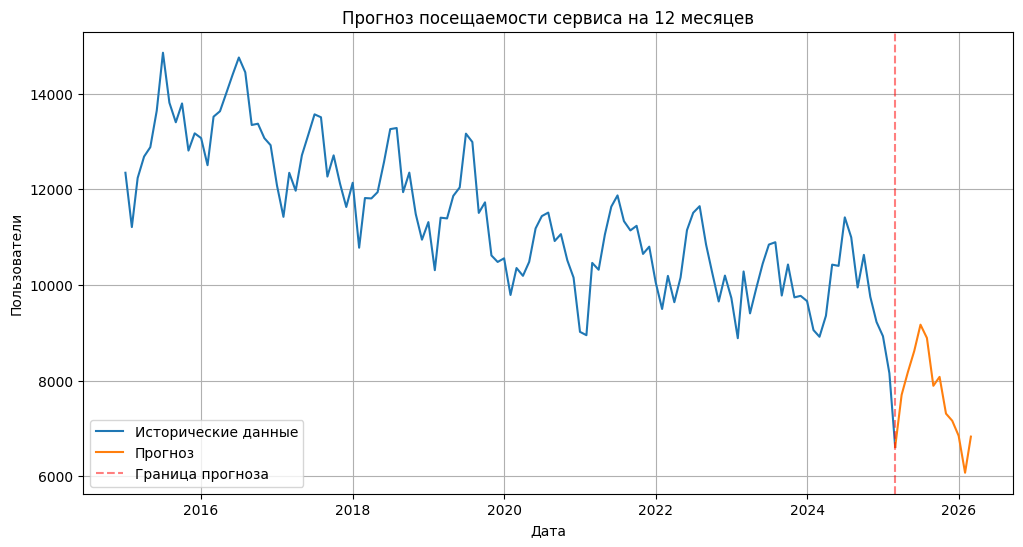

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts.values, label='Исторические данные')

# склеиваем последнюю точку ts и первую forecast, чтобы небло пустоты
bridge = pd.concat([ts.iloc[[-1]], forecast])
plt.plot(bridge.index, bridge.values, label='Прогноз')

plt.axvline(ts.index[-1], color='red', linestyle='--', alpha=0.5, label='Граница прогноза')
plt.title('Прогноз посещаемости сервиса на 12 месяцев')
plt.xlabel('Дата')
plt.ylabel('Пользователи')
plt.legend()
plt.grid()
plt.show()